# Create the dataset for computation

In [1]:
import datasets
import pandas as pd
import numpy as np

from utils.utils_data2 import (
    load_pred_and_emb,
    center_and_norm,
    get_pca,
    get_cluster,
    get_similarities,
    add_lags_and_scale_data,
    compute_neighbors_and_distances,
    compute_neighbor_weighted_prices,
)

In [2]:
txt_only = False
include_embeddings = True
dataframe_name = f"dataset_txt_only_{txt_only}_embeddings_{include_embeddings}"

In [3]:
window = 28
mod = 4
max_periods = 54

ds_dict = datasets.load_dataset("DoubleML/amzn_toys_monthly_diffs_ffill_fixed_splits_buybox")

ds_val = ds_dict['validation']
ds_train = ds_dict['train']

columns = ['ASIN',
           'SALES_RANK',
           'PRICE',
           'BUYBOX_PRICE',
           'text',
           'date',
           'window',
           'REVIEW_COUNT',
           'RATING',
           'New Offer Count: Current',
           'Count of retrieved live offers: New, FBA',
           'Count of retrieved live offers: New, FBM',
           'Lightning Deals: Upcoming Deal',
           'Buy Box: Is FBA',
           'subcat_aggregated']

df_val = ds_val.select_columns(columns).to_pandas()
df_val = df_val[df_val["window"] == window].dropna()
df_val["date_t"] = df_val["date"].astype("category").cat.codes
df_val = df_val[df_val["date_t"] <= max_periods]
df_val = df_val[df_val["date_t"] % mod == 0]

df_train = ds_train.select_columns(columns).to_pandas()
df_train = df_train[df_train["window"] == window].dropna()
df_train["date_t"] = df_train["date"].astype("category").cat.codes
df_train = df_train[df_train["date_t"] <= max_periods]
df_train = df_train[df_train["date_t"] % mod == 0]


df_train_val = pd.concat([df_train, df_val], axis=0).reset_index()

# Dataset contains data with different averaged values (by window size).
# Predictions / Embeddings only for one specific window size

num_val = len(df_val)
num_train = len(df_train)

print(f"Number of train samples: {num_train}")
print(f"Number of val samples: {num_val}")

# Create dummy variables for the subcategories
dummy_subcat = pd.get_dummies(df_train_val["subcat_aggregated"]) * 1
dummy_subcat_names = list(dummy_subcat.columns)
dummy_time = pd.get_dummies(df_train_val["date"]) * 1
dummy_time_names = list(dummy_time.columns)

df_train_val = pd.concat([df_train_val, dummy_subcat, dummy_time], axis=1)

df_full = pd.concat([df_train_val, dummy_subcat], axis=1)
df_full.set_index(["ASIN", "date"], inplace=True)

print(f"df_full shape: {df_full.shape}")
print(df_full.columns)

Number of train samples: 41945
Number of val samples: 41832
df_full shape: (83777, 51)
Index(['index', 'SALES_RANK', 'PRICE', 'BUYBOX_PRICE', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       'Count of retrieved live offers: New, FBM',
       'Lightning Deals: Upcoming Deal', 'Buy Box: Is FBA',
       'subcat_aggregated', 'date_t', 'Airplanes', 'Cars & Race Cars',
       'Motor Vehicles', 'Race Tracks', 'Residual', 'Skateboards', 'Tractors',
       'Train Sets', 'Trains & Trams', 'Trucks', 'Vehicle Playsets',
       '2023-01-30', '2023-02-27', '2023-03-27', '2023-04-24', '2023-05-22',
       '2023-06-19', '2023-07-17', '2023-08-14', '2023-09-11', '2023-10-09',
       '2023-11-06', '2023-12-04', '2024-01-01', '2024-01-29', 'Airplanes',
       'Cars & Race Cars', 'Motor Vehicles', 'Race Tracks', 'Residual',
       'Skateboards', 'Tractors', 'Train Sets', 'Trains & Trams', 'Trucks',
       'Vehicle Play

In [4]:
results_256_time_independent, configs_time_independent = load_pred_and_emb(
        embedding_size=256,
        txt_only=txt_only,
        lag_type="time_independent",
        config_path="utils/paths_config.yaml",
        get_lag2_for_diff=False,
    )


results_256_lag1, configs_lag1 = load_pred_and_emb(
        embedding_size=256,
        txt_only=txt_only,
        lag_type="lag1",
        config_path="utils/paths_config.yaml",
        get_lag2_for_diff=False,
    )

if not txt_only:
    results_256_lag2, configs_lag2 = load_pred_and_emb(
            embedding_size=256,
            txt_only=txt_only,
            lag_type="lag1",
            config_path="utils/paths_config.yaml",
            get_lag2_for_diff=False,
        )

[INFO] Shapes for embeddings & predictions (level/diff) loaded:
  - val_embeddings_levl:     (41832, 268)
  - val_embeddings_diff:     (38041, 130)
  - train_embeddings_levl:   (41945, 268)
  - val_predictions_levl:    (41832, 4)
  - val_predictions_diff:    (38041, 4)
  - train_predictions_levl:  (41945, 4)
  - train_predictions_diff:  (38146, 4)
[INFO] Shapes for embeddings & predictions (level/diff) loaded:
  - val_embeddings_levl:     (38203, 268)
  - val_embeddings_diff:     (38041, 130)
  - train_embeddings_levl:   (38309, 268)
  - val_predictions_levl:    (38203, 4)
  - val_predictions_diff:    (38041, 4)
  - train_predictions_levl:  (38309, 4)
  - train_predictions_diff:  (38146, 4)
[INFO] Shapes for embeddings & predictions (level/diff) loaded:
  - val_embeddings_levl:     (38203, 268)
  - val_embeddings_diff:     (38041, 130)
  - train_embeddings_levl:   (38309, 268)
  - val_predictions_levl:    (38203, 4)
  - val_predictions_diff:    (38041, 4)
  - train_predictions_levl:  (

## Create Embeddings, Similarites and PCA based on time independent embeddings

In [5]:
pred_and_emb = results_256_time_independent
embeddings = center_and_norm(pred_and_emb["embeddings"][2], pred_and_emb["embeddings"][0])
print(f"Embedding shape: {embeddings.shape}")
_, cluster_centroids = get_cluster(embeddings, n_clusters=5, n_init=200)
pca_results = get_pca(embeddings, n_components=5)
df_pca = pd.DataFrame(pca_results, columns=[f"pca_{i}" for i in range(pca_results.shape[1])])
df_sim = get_similarities(embeddings, cluster_centroids)

print(f"pca columns: {df_pca.columns}")
print(f"sim columns: {df_sim.columns}")

Embedding shape: (83777, 266)
pca columns: Index(['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4'], dtype='object')
sim columns: Index(['similarity_cluster_0', 'similarity_cluster_1', 'similarity_cluster_2',
       'similarity_cluster_3', 'similarity_cluster_4'],
      dtype='object')


In [6]:
# join to dataframe
df_full = df_full.join(df_pca)
df_full = df_full.join(df_sim)

if include_embeddings:
    df_full = df_full.join(embeddings.add_prefix("emb_"))

In [7]:
df_full.head()

index  SALES_RANK     PRICE  BUYBOX_PRICE  \
ASIN       date                                                    
1947335162 2023-01-30      1  -12.747395  3.400864      3.555062   
           2023-02-27      9  -12.600586  3.404632      3.555062   
           2023-03-27     17  -12.515369  3.427422      3.633271   
           2023-04-24     25  -12.576837  3.400864      3.582963   
           2023-05-22     33  -12.688608  3.400864      3.587493   

                                                                    text  \
ASIN       date                                                            
1947335162 2023-01-30  Catalyst Game Labs Battletech: Technical Reado...   
           2023-02-27  Catalyst Game Labs Battletech: Technical Reado...   
           2023-03-27  Catalyst Game Labs Battletech: Technical Reado...   
           2023-04-24  Catalyst Game Labs Battletech: Technical Reado...   
           2023-05-22  Catalyst Game Labs Battletech: Technical Reado...   

                       window  REVIEW_COUNT    RATING  \
ASIN       date                                         
1947335162 2023-01-30    28.0     62.000000  4.700000   
           2023-02-27    28.0     62.000000  4.700000   
           2023-03-27    28.0     62.035714  4.678571   
           2023-04-24    28.0     63.607143  4.700000   
           2023-05-22    28.0     64.000000  4.700000   

                       New Offer Count: Current  \
ASIN       date                                   
1947335162 2023-01-30                        10   
           2023-02-27                        10   
           2023-03-27                        10   
           2023-04-24                        10   
           2023-05-22                        10   

                       Count of retrieved live offers: New, FBA  ...  \
ASIN       date                                                  ...   
1947335162 2023-01-30                                         2  ...   
           2023-02-27                                         2  ...   
           2023-03-27                                         2  ...   
           2023-04-24                                         2  ...   
           2023-05-22                                         2  ...   

                        emb_256   emb_257   emb_258   emb_259   emb_260  \
ASIN       date                                                           
1947335162 2023-01-30  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-02-27  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-03-27  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-04-24  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-05-22  0.004696  0.042513 -0.019874  0.022446  0.014005   

                        emb_261   emb_262   emb_263   emb_264   emb_265  
ASIN       date                                                          
1947335162 2023-01-30 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-02-27 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-03-27 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-04-24 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-05-22 -0.065006  0.062708  0.028028  0.055719  0.025836  

[5 rows x 327 columns]

In [8]:
## add treatment_features and outcome_features

t_f = [f"treatment_feature_{i}" for i in range(5)]
o_f = [f"outcome_feature_{i}" for i in range(5)]

treat_features_val = results_256_time_independent["embeddings"][0][["ASIN", "date"] + t_f]
treat_features_trn = results_256_time_independent["embeddings"][2][["ASIN", "date"] + t_f]
outcome_features_val = results_256_time_independent["embeddings"][0][["ASIN", "date"] + o_f]
outcome_features_trn = results_256_time_independent["embeddings"][2][["ASIN", "date"] + o_f]

treat_features = pd.concat([treat_features_trn, treat_features_val], axis=0)
outcome_features = pd.concat([outcome_features_trn, outcome_features_val], axis=0)

In [9]:
treat_features.describe()

,treatment_feature_0,treatment_feature_1,treatment_feature_2,treatment_feature_3,treatment_feature_4
count,83777.000000,83777.000000,83777.000000,83777.000000,83777.000000
mean,1.119707,-0.999059,2.342499,1.615736,-0.941193
std,0.354755,0.002171,0.711403,0.593751,0.120670
min,0.339052,-1.000000,0.946010,0.618081,-1.000000
25%,0.902522,-0.999991,1.856623,1.201175,-0.996886
50%,1.127737,-0.999936,2.296035,1.537513,-0.990389
75%,1.320284,-0.999470,2.697900,1.882393,-0.961678
max,4.993724,-0.976714,7.933744,7.733071,-0.355132


In [10]:
outcome_features.describe()

,outcome_feature_0,outcome_feature_1,outcome_feature_2,outcome_feature_3,outcome_feature_4
count,83777.000000,83777.000000,83777.000000,83777.000000,83777.000000
mean,6.385733,-0.999998,-0.999999,-0.999998,14.064500
std,0.859778,0.000042,0.000019,0.000033,1.582806
min,1.625812,-1.000000,-1.000000,-1.000000,4.817544
25%,5.976725,-1.000000,-1.000000,-1.000000,13.260629
50%,6.551597,-1.000000,-1.000000,-1.000000,14.388371
75%,6.973767,-1.000000,-1.000000,-1.000000,15.157073
max,8.513037,-0.997060,-0.999066,-0.997997,17.660358


In [11]:
# join features on index
treat_features.set_index(["ASIN", "date"], inplace=True)
outcome_features.set_index(["ASIN", "date"], inplace=True)

In [12]:
df_full.shape

(83777, 327)

In [13]:
treat_features

treatment_feature_0  treatment_feature_1  \
ASIN       date                                                   
1947335162 2023-01-30             1.383525            -0.999996   
           2023-02-27             1.383525            -0.999996   
           2023-03-27             1.383525            -0.999996   
           2023-04-24             1.383525            -0.999996   
           2023-05-22             1.383525            -0.999996   
...                                    ...                  ...   
B0CQWJ3247 2024-01-01             0.575173            -0.995419   
           2024-01-29             0.574239            -0.995385   
B0CQWJZGSY 2024-01-01             0.509510            -0.996056   
           2024-01-29             0.510133            -0.996082   
B0CRDLRP38 2024-01-29             1.331931            -0.999993   

                       treatment_feature_2  treatment_feature_3  \
ASIN       date                                                   
1947335162 2023-01-30             2.769176             2.090240   
           2023-02-27             2.769176             2.090240   
           2023-03-27             2.769176             2.090240   
           2023-04-24             2.769176             2.090240   
           2023-05-22             2.769176             2.090240   
...                                    ...                  ...   
B0CQWJ3247 2024-01-01             1.387224             0.953278   
           2024-01-29             1.387585             0.951113   
B0CQWJZGSY 2024-01-01             1.470235             0.951500   
           2024-01-29             1.469720             0.953938   
B0CRDLRP38 2024-01-29             2.740521             1.910603   

                       treatment_feature_4  
ASIN       date                             
1947335162 2023-01-30            -0.997832  
           2023-02-27            -0.997832  
           2023-03-27            -0.997832  
           2023-04-24            -0.997832  
           2023-05-22            -0.997832  
...                                    ...  
B0CQWJ3247 2024-01-01            -0.722598  
           2024-01-29            -0.721984  
B0CQWJZGSY 2024-01-01            -0.728100  
           2024-01-29            -0.728720  
B0CRDLRP38 2024-01-29            -0.997380  

[83777 rows x 5 columns]

In [14]:
print(outcome_features.shape)
print(treat_features.shape)

(83777, 5)
(83777, 5)


In [15]:
df_full.head()

index  SALES_RANK     PRICE  BUYBOX_PRICE  \
ASIN       date                                                    
1947335162 2023-01-30      1  -12.747395  3.400864      3.555062   
           2023-02-27      9  -12.600586  3.404632      3.555062   
           2023-03-27     17  -12.515369  3.427422      3.633271   
           2023-04-24     25  -12.576837  3.400864      3.582963   
           2023-05-22     33  -12.688608  3.400864      3.587493   

                                                                    text  \
ASIN       date                                                            
1947335162 2023-01-30  Catalyst Game Labs Battletech: Technical Reado...   
           2023-02-27  Catalyst Game Labs Battletech: Technical Reado...   
           2023-03-27  Catalyst Game Labs Battletech: Technical Reado...   
           2023-04-24  Catalyst Game Labs Battletech: Technical Reado...   
           2023-05-22  Catalyst Game Labs Battletech: Technical Reado...   

                       window  REVIEW_COUNT    RATING  \
ASIN       date                                         
1947335162 2023-01-30    28.0     62.000000  4.700000   
           2023-02-27    28.0     62.000000  4.700000   
           2023-03-27    28.0     62.035714  4.678571   
           2023-04-24    28.0     63.607143  4.700000   
           2023-05-22    28.0     64.000000  4.700000   

                       New Offer Count: Current  \
ASIN       date                                   
1947335162 2023-01-30                        10   
           2023-02-27                        10   
           2023-03-27                        10   
           2023-04-24                        10   
           2023-05-22                        10   

                       Count of retrieved live offers: New, FBA  ...  \
ASIN       date                                                  ...   
1947335162 2023-01-30                                         2  ...   
           2023-02-27                                         2  ...   
           2023-03-27                                         2  ...   
           2023-04-24                                         2  ...   
           2023-05-22                                         2  ...   

                        emb_256   emb_257   emb_258   emb_259   emb_260  \
ASIN       date                                                           
1947335162 2023-01-30  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-02-27  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-03-27  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-04-24  0.004696  0.042513 -0.019874  0.022446  0.014005   
           2023-05-22  0.004696  0.042513 -0.019874  0.022446  0.014005   

                        emb_261   emb_262   emb_263   emb_264   emb_265  
ASIN       date                                                          
1947335162 2023-01-30 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-02-27 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-03-27 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-04-24 -0.065006  0.062708  0.028028  0.055719  0.025836  
           2023-05-22 -0.065006  0.062708  0.028028  0.055719  0.025836  

[5 rows x 327 columns]

In [16]:
df_full = df_full.join(outcome_features)
df_full = df_full.join(treat_features)


df_full.shape

(83777, 337)

### Generate weighted substitute price feature

In [17]:
df_neighbor_asins_by_date, df_distance_df_by_date = compute_neighbors_and_distances(embeddings, n_neighbors=5)

df_full = df_full.join(df_neighbor_asins_by_date)
df_full = df_full.join(df_distance_df_by_date)

print(f"df_full shape after joining embeddings and neighbors: {df_full.shape}")

Combined neighbor ASINs shape: (83777, 5)
Combined neighbor distances shape: (83777, 5)
df_full shape after joining embeddings and neighbors: (83777, 347)


In [18]:
df_full.head()

index  SALES_RANK     PRICE  BUYBOX_PRICE  \
ASIN       date                                                    
1947335162 2023-01-30      1  -12.747395  3.400864      3.555062   
           2023-02-27      9  -12.600586  3.404632      3.555062   
           2023-03-27     17  -12.515369  3.427422      3.633271   
           2023-04-24     25  -12.576837  3.400864      3.582963   
           2023-05-22     33  -12.688608  3.400864      3.587493   

                                                                    text  \
ASIN       date                                                            
1947335162 2023-01-30  Catalyst Game Labs Battletech: Technical Reado...   
           2023-02-27  Catalyst Game Labs Battletech: Technical Reado...   
           2023-03-27  Catalyst Game Labs Battletech: Technical Reado...   
           2023-04-24  Catalyst Game Labs Battletech: Technical Reado...   
           2023-05-22  Catalyst Game Labs Battletech: Technical Reado...   

                       window  REVIEW_COUNT    RATING  \
ASIN       date                                         
1947335162 2023-01-30    28.0     62.000000  4.700000   
           2023-02-27    28.0     62.000000  4.700000   
           2023-03-27    28.0     62.035714  4.678571   
           2023-04-24    28.0     63.607143  4.700000   
           2023-05-22    28.0     64.000000  4.700000   

                       New Offer Count: Current  \
ASIN       date                                   
1947335162 2023-01-30                        10   
           2023-02-27                        10   
           2023-03-27                        10   
           2023-04-24                        10   
           2023-05-22                        10   

                       Count of retrieved live offers: New, FBA  ...  \
ASIN       date                                                  ...   
1947335162 2023-01-30                                         2  ...   
           2023-02-27                                         2  ...   
           2023-03-27                                         2  ...   
           2023-04-24                                         2  ...   
           2023-05-22                                         2  ...   

                       neighbor_asin_1  neighbor_asin_2  neighbor_asin_3  \
ASIN       date                                                            
1947335162 2023-01-30       B09XCR1DFQ       B00B185J3I       B08R61SDHY   
           2023-02-27       B09XCR1DFQ       B00B185J3I       B08R61SDHY   
           2023-03-27       B09XCR1DFQ       B00B185J3I       B08R61SDHY   
           2023-04-24       B09XCR1DFQ       B00B185J3I       B08R61SDHY   
           2023-05-22       B09XCR1DFQ       B00B185J3I       B08R61SDHY   

                      neighbor_asin_4  neighbor_asin_5  neighbor_distance_1  \
ASIN       date                                                               
1947335162 2023-01-30      B09582YPVV       B000BL8JKG              0.18389   
           2023-02-27      B09582YPVV       B000BL8JKG              0.18389   
           2023-03-27      B09582YPVV       B000BL8JKG              0.18389   
           2023-04-24      B09582YPVV       B000BL8JKG              0.18389   
           2023-05-22      B09582YPVV       B000BL8JKG              0.18389   

                       neighbor_distance_2  neighbor_distance_3  \
ASIN       date                                                   
1947335162 2023-01-30             0.194322             0.207955   
           2023-02-27             0.194322             0.209324   
           2023-03-27             0.194322             0.209324   
           2023-04-24             0.194322             0.209324   
           2023-05-22             0.194322             0.209324   

                       neighbor_distance_4  neighbor_distance_5  
ASIN       date                                                  
1947335162 2023-01-30             0.210860             0.2136

In [19]:
[x for x in df_full.columns if "outcome" in x.lower()]

['outcome_feature_0',
 'outcome_feature_1',
 'outcome_feature_2',
 'outcome_feature_3',
 'outcome_feature_4']

In [20]:
weighted_substitute_price = compute_neighbor_weighted_prices(df_full.drop(columns=t_f + o_f), 'BUYBOX_PRICE')
df_full = df_full.join(weighted_substitute_price)
df_full.loc[:, ['BUYBOX_PRICE', 'weighted_substitute_price']].head()

Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 neighbor ASIN columns.
Found 5 

BUYBOX_PRICE  weighted_substitute_price
ASIN       date                                               
1947335162 2023-01-30      3.555062                   3.649699
           2023-02-27      3.555062                   3.694722
           2023-03-27      3.633271                   3.738346
           2023-04-24      3.582963                   3.740850
           2023-05-22      3.587493                   3.745487

In [21]:
df_full_val = df_full.iloc[num_train:, :]
df_full_train = df_full.iloc[:num_train, :]

print(f"df_full shape: {df_full.shape}")
print(f"df_full_train shape: {df_full_train.shape}")
print(f"df_full_val shape: {df_full_val.shape}")
print(df_full.columns)

df_full shape: (83777, 348)
df_full_train shape: (41945, 348)
df_full_val shape: (41832, 348)
Index(['index', 'SALES_RANK', 'PRICE', 'BUYBOX_PRICE', 'text', 'window',
       'REVIEW_COUNT', 'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'neighbor_asin_2', 'neighbor_asin_3', 'neighbor_asin_4',
       'neighbor_asin_5', 'neighbor_distance_1', 'neighbor_distance_2',
       'neighbor_distance_3', 'neighbor_distance_4', 'neighbor_distance_5',
       'weighted_substitute_price'],
      dtype='object', length=348)


In [22]:
df_full_val = df_full_val.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"})

for i in range(1, 3):
    df_full_val[f"Q_t-{i}"] = df_full_val.groupby("ASIN")["Q_t"].shift(i)
    df_full_val[f"P_bb_t-{i}"] = df_full_val.groupby("ASIN")["P_bb_t"].shift(i)
    df_full_val[f"REVIEW_COUNT_t-{i}"] = df_full_val["REVIEW_COUNT"].groupby("ASIN").shift(i)
    df_full_val[f"RATING_t-{i}"] = df_full_val["RATING"].groupby("ASIN").shift(i)

df_full_val["Delta_Q_t"] = df_full_val["Q_t"] - df_full_val["Q_t-1"]
df_full_val["Delta_P_bb_t"] = df_full_val["P_bb_t"] - df_full_val["P_bb_t-1"]


df_full_train.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"}, inplace=True)
for i in range(1, 3):
    df_full_train[f"Q_t-{i}"] = df_full_train["Q_t"].groupby("ASIN").shift(i)
    df_full_train[f"P_bb_t-{i}"] = df_full_train["P_bb_t"].groupby("ASIN").shift(i)
    df_full_train[f"REVIEW_COUNT_t-{i}"] = df_full_train["REVIEW_COUNT"].groupby("ASIN").shift(i)
    df_full_train[f"RATING_t-{i}"] = df_full_train["RATING"].groupby("ASIN").shift(i)
    
df_full_train["Delta_Q_t"] = df_full_train["Q_t"] - df_full_train["Q_t-1"]
df_full_train["Delta_P_bb_t"] = df_full_train["P_bb_t"] - df_full_train["P_bb_t-1"]


val_predictions_levl = pred_and_emb["predictions"][0]
val_predictions_diff = pred_and_emb["predictions"][1].rename(columns={"pred_ml_l": "pred_ml_l_diff", "pred_ml_m": "pred_ml_m_diff"})
train_predictions_levl = pred_and_emb["predictions"][2]
train_predictions_diff = pred_and_emb["predictions"][3].rename(columns={"pred_ml_l": "pred_ml_l_diff", "pred_ml_m": "pred_ml_m_diff"})

df_full_val = df_full_val.join(val_predictions_levl.set_index(["ASIN", "date"]))
df_full_train = df_full_train.join(train_predictions_levl.set_index(["ASIN", "date"]))
df_full_val = df_full_val.join(val_predictions_diff.set_index(["ASIN", "date"]))
df_full_train = df_full_train.join(train_predictions_diff.set_index(["ASIN", "date"]))

print(f"df_full_train shape: {df_full_train.shape}")
print(f"df_full_val shape: {df_full_val.shape}")

print(f"df_full_train columns: {df_full_train.columns}")
print(f"df_full_val columns: {df_full_val.columns}")

C:\Users\Work\AppData\Local\Temp\ipykernel_25096\522145330.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_train.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"}, inplace=True)
C:\Users\Work\AppData\Local\Temp\ipykernel_25096\522145330.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_full_train[f"Q_t-{i}"] = df_full_train["Q_t"].groupby("ASIN").shift(i)
C:\Users\Work\AppData\Local\Temp\ipykernel_25096\522145330.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

df_full_train shape: (41945, 362)
df_full_val shape: (41832, 362)
df_full_train columns: Index(['index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT',
       'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'Q_t-2', 'P_bb_t-2', 'REVIEW_COUNT_t-2', 'RATING_t-2', 'Delta_Q_t',
       'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff',
       'pred_ml_m_diff'],
      dtype='object', length=362)
df_full_val columns: Index(['index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT',
       'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'Q_t-2', 'P_bb_t-2', 'REVIEW_COUNT_t-2', 'RATING_t-2', 'Delta_Q_t',
       'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff',
       'pred_ml_m_diff'],
      dtype='object', length=362)


### Add Lag 1 predictions to the dataset

In [23]:
val_predictions_levl_lag1 = results_256_lag1["predictions"][0].rename(columns={"pred_ml_l": "pred_ml_l_lag_1", "pred_ml_m": "pred_ml_m_lag_1"})
val_predictions_diff_lag1 = results_256_lag1["predictions"][1].rename(columns={"pred_ml_l": "pred_ml_l_diff_lag_1", "pred_ml_m": "pred_ml_m_diff_lag_1"})
train_predictions_levl_lag1 = results_256_lag1["predictions"][2].rename(columns={"pred_ml_l": "pred_ml_l_lag_1", "pred_ml_m": "pred_ml_m_lag_1"})
train_predictions_diff_lag1 = results_256_lag1["predictions"][3].rename(columns={"pred_ml_l": "pred_ml_l_diff_lag_1", "pred_ml_m": "pred_ml_m_diff_lag_1"})

df_full_val = df_full_val.join(val_predictions_levl_lag1.set_index(["ASIN", "date"]))
df_full_train = df_full_train.join(train_predictions_levl_lag1.set_index(["ASIN", "date"]))
df_full_val = df_full_val.join(val_predictions_diff_lag1.set_index(["ASIN", "date"]))
df_full_train = df_full_train.join(train_predictions_diff_lag1.set_index(["ASIN", "date"]))

print(f"df_full_train shape: {df_full_train.shape}")
print(f"df_full_val shape: {df_full_val.shape}")

print(f"df_full_train columns: {df_full_train.columns}")
print(f"df_full_val columns: {df_full_val.columns}")

df_full_train shape: (41945, 366)
df_full_val shape: (41832, 366)
df_full_train columns: Index(['index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT',
       'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'Delta_Q_t', 'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff',
       'pred_ml_m_diff', 'pred_ml_l_lag_1', 'pred_ml_m_lag_1',
       'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1'],
      dtype='object', length=366)
df_full_val columns: Index(['index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT',
       'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'Delta_Q_t', 'Delta_P_bb_t', 'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff',
       'pred_ml_m_diff', 'pred_ml_l_lag_1', 'pred_ml_m_lag_1',
       'pred_ml_l_diff_lag_1', 'pred_ml_m_diff_lag_1'],
      dtype='object', length=366)


### Add Lag 2 predictions to the dataset

In [24]:
if not txt_only:
    val_predictions_diff_lag2 = results_256_lag2["predictions"][1].rename(columns={"pred_ml_l": "pred_ml_l_diff_lag_2", "pred_ml_m": "pred_ml_m_diff_lag_2"})
    train_predictions_diff_lag2 = results_256_lag2["predictions"][3].rename(columns={"pred_ml_l": "pred_ml_l_diff_lag_2", "pred_ml_m": "pred_ml_m_diff_lag_2"})

    df_full_val = df_full_val.join(val_predictions_diff_lag2.set_index(["ASIN", "date"]))
    df_full_train = df_full_train.join(train_predictions_diff_lag2.set_index(["ASIN", "date"]))

    print(f"df_full_train shape: {df_full_train.shape}")
    print(f"df_full_val shape: {df_full_val.shape}")

    print(f"df_full_train columns: {df_full_train.columns}")
    print(f"df_full_val columns: {df_full_val.columns}")
    print(configs_lag2)
else:
    print("Skipping lag2")

df_full_train shape: (41945, 368)
df_full_val shape: (41832, 368)
df_full_train columns: Index(['index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT',
       'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff', 'pred_ml_m_diff',
       'pred_ml_l_lag_1', 'pred_ml_m_lag_1', 'pred_ml_l_diff_lag_1',
       'pred_ml_m_diff_lag_1', 'pred_ml_l_diff_lag_2', 'pred_ml_m_diff_lag_2'],
      dtype='object', length=368)
df_full_val columns: Index(['index', 'Q_t', 'PRICE', 'P_bb_t', 'text', 'window', 'REVIEW_COUNT',
       'RATING', 'New Offer Count: Current',
       'Count of retrieved live offers: New, FBA',
       ...
       'pred_ml_l', 'pred_ml_m', 'pred_ml_l_diff', 'pred_ml_m_diff',
       'pred_ml_l_lag_1', 'pred_ml_m_lag_1', 'pred_ml_l_diff_lag_1',
       'pred_ml_m_diff_lag_1', 'pred_ml_l_diff_lag_2', 'pred_ml_m_diff_lag_2'],
      dtype='object', length=368)
({'train': 'predicti

write to csv 

In [25]:
df_full_train.to_csv(f"predictions_v2/datasets/{dataframe_name}_train.csv")
df_full_val.to_csv(f"predictions_v2/datasets/{dataframe_name}_val.csv")

Text(0.5, 1.0, 'Distribution of BUYBOX_PRICE - weighted_substitute_price')

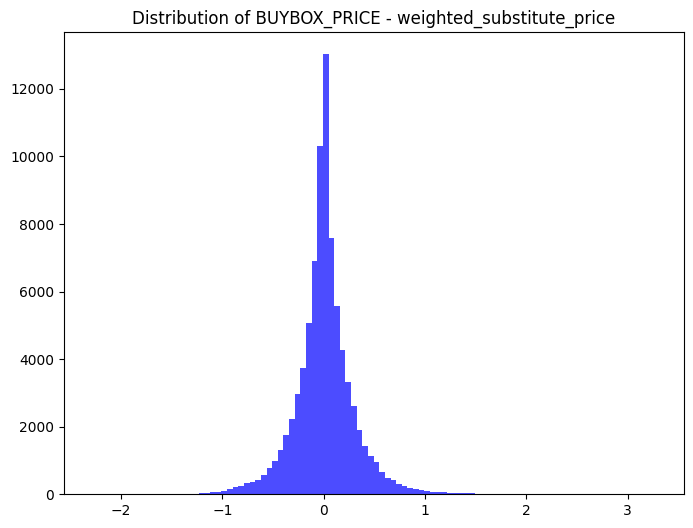

In [26]:
# plot distribution of BUYBOX_PRICE - weighted_substitute_price

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.hist(df_full['BUYBOX_PRICE'] - df_full['weighted_substitute_price'], bins=100, color='blue', alpha=0.7)
plt.title('Distribution of BUYBOX_PRICE - weighted_substitute_price')